In [20]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import signal
from scipy.fft import rfft, rfftfreq

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set(style="whitegrid")

FS = 2000
DATA_DIR = Path("/home/mamunds/job/pyspark/konux/data")


In [21]:
def load_binary_signal(filepath):
    return np.fromfile(filepath, dtype=np.float32)

def parse_filename_metadata(filename):
    meta = {}
    m = re.match(r"(\d{8})_(\d{6})_(\d+)_", filename)
    if m:
        meta["date"], meta["time"], meta["sensor_id"] = m.groups()
    return meta

def bandpass_filter_zero_phase(x, fs, low=5, high=500, order=4):
    x = x - np.mean(x)
    b, a = signal.butter(order, [low/(fs/2), high/(fs/2)], btype="band")
    return signal.filtfilt(b, a, x)

def rms_envelope(x, fs, window_s=0.05):
    w = max(1, int(window_s * fs))
    return np.sqrt(np.convolve(x**2, np.ones(w)/w, mode="same"))

def segment_active_region(env, fs):
    baseline = env[:int(0.5*fs)]
    thr = np.mean(baseline) + 3*np.std(baseline)
    idx = np.where(env > thr)[0]
    if len(idx) == 0:
        return 0, len(env)
    return idx[0], idx[-1]

def extract_time_features(x, fs):
    peaks, _ = signal.find_peaks(np.abs(x), height=np.std(x))
    return {
        "rms": np.sqrt(np.mean(x**2)),
        "peak_to_peak": np.max(x) - np.min(x),
        "num_peaks": len(peaks),
        "mean_peak_interval_s": np.mean(np.diff(peaks))/fs if len(peaks) > 1 else np.nan
    }

def extract_frequency_features(x, fs):
    yf = np.abs(rfft(x))
    xf = rfftfreq(len(x), 1/fs)
    centroid = np.sum(xf*yf)/np.sum(yf)
    dom = xf[np.argmax(yf)]
    return {
        "spectral_centroid_hz": centroid,
        "dominant_frequency_hz": dom
    }


In [22]:
signals = {}
rows = []

for fp in DATA_DIR.glob("*.bin"):
    x = load_binary_signal(fp)
    signals[fp.name] = x
    meta = parse_filename_metadata(fp.name)
    rows.append({"file": fp.name, **meta, "duration_s": len(x)/FS})

meta_df = pd.DataFrame(rows).set_index("file")
meta_df


,date,time,sensor_id,duration_s
file,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,8.0
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,20.0
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,12.0
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,8.0
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,6.0
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,17.0
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,7.0
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,8.0
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,12.0


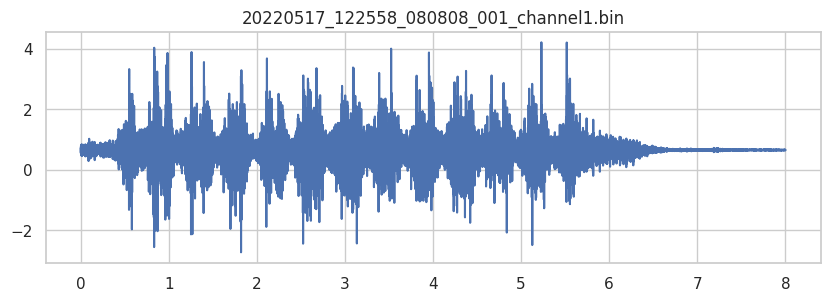

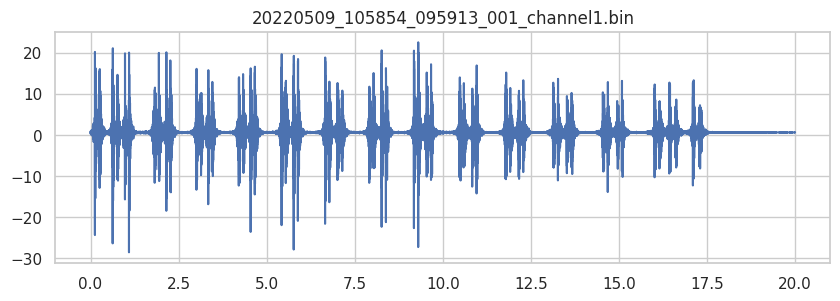

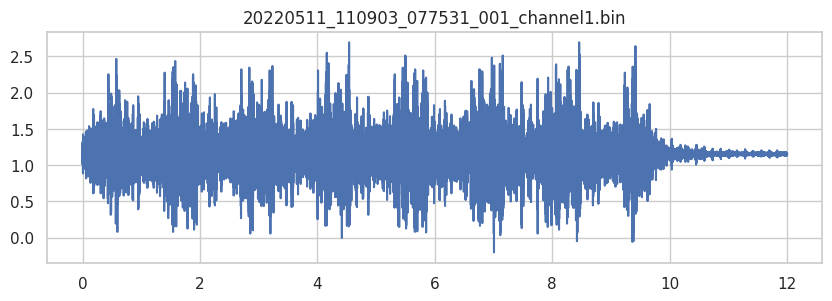

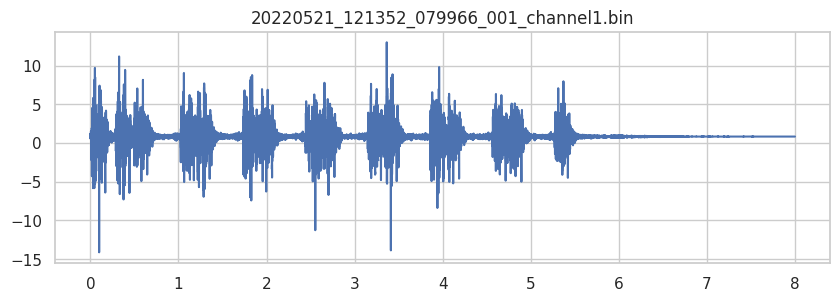

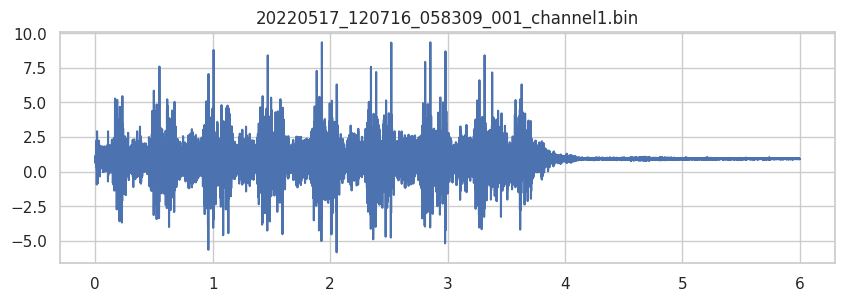

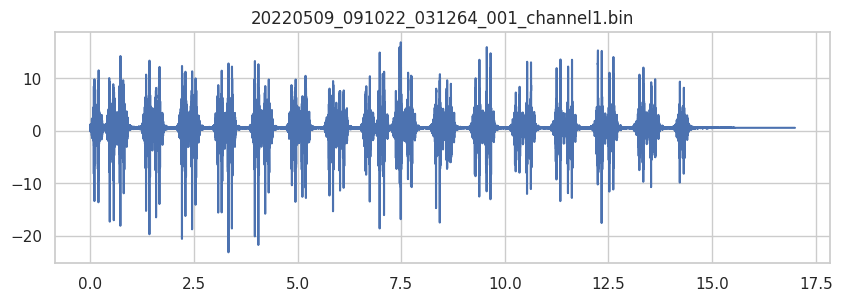

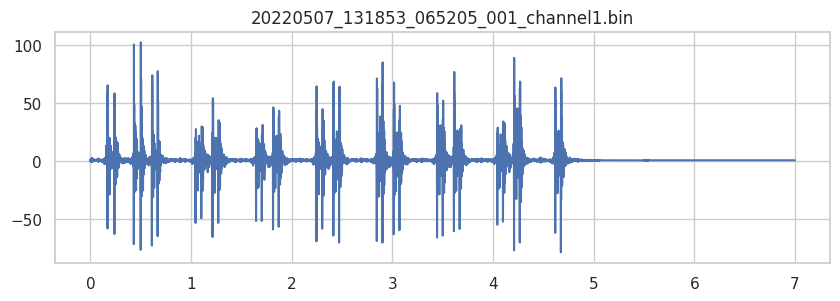

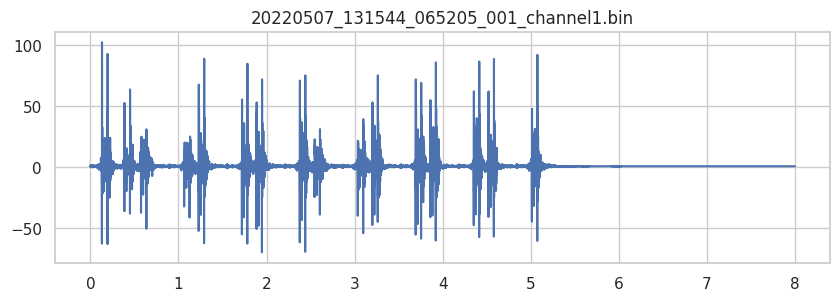

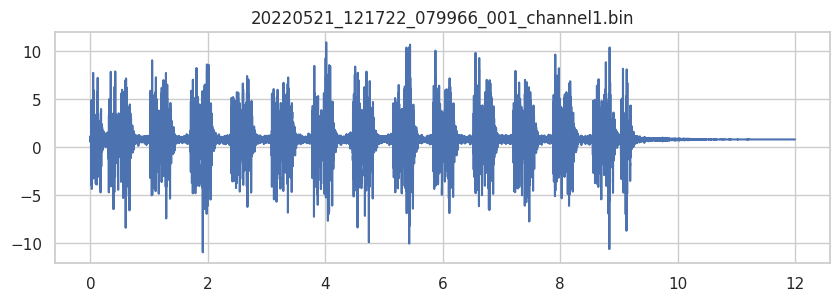

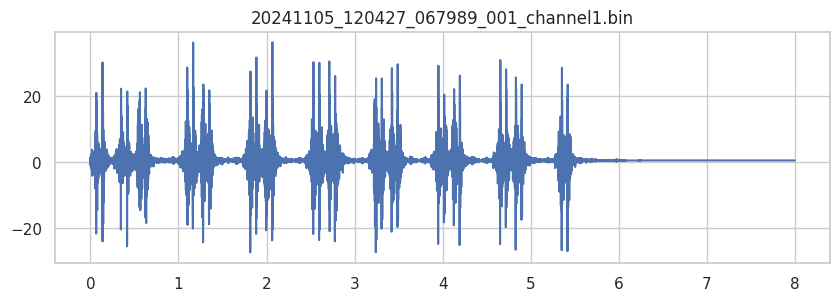

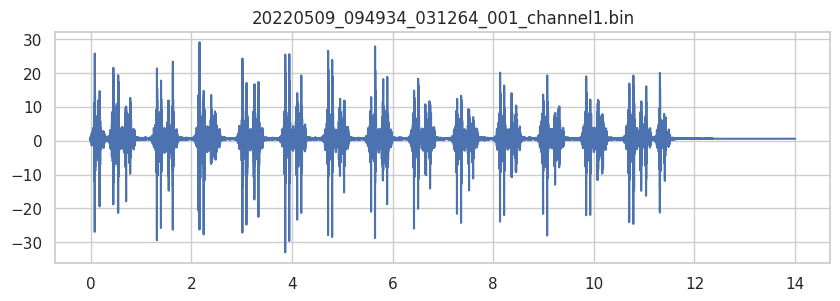

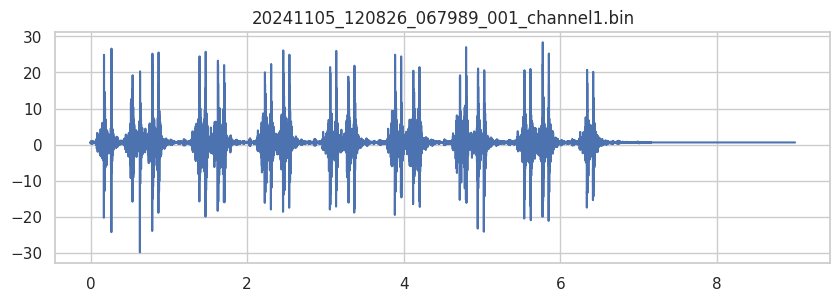

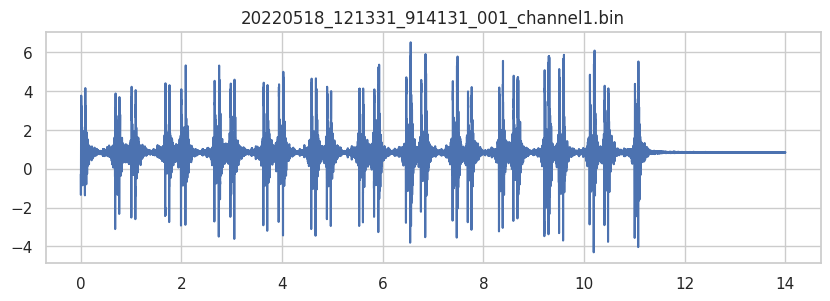

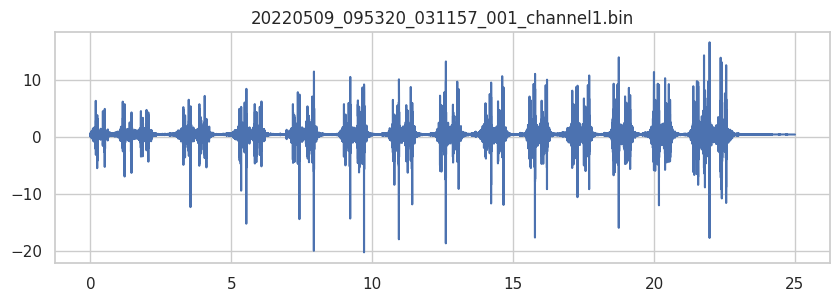

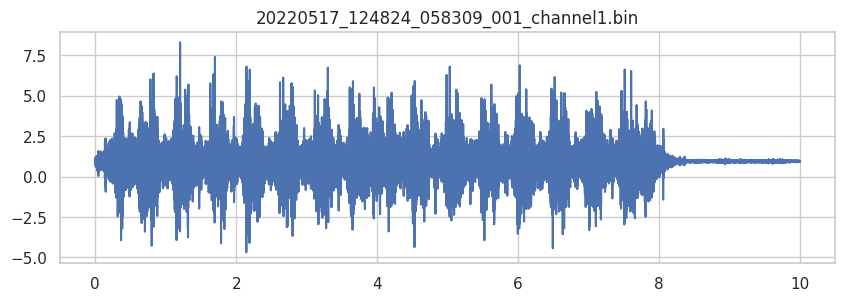

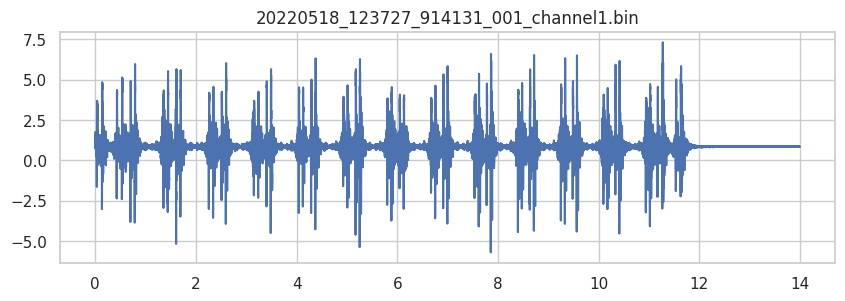

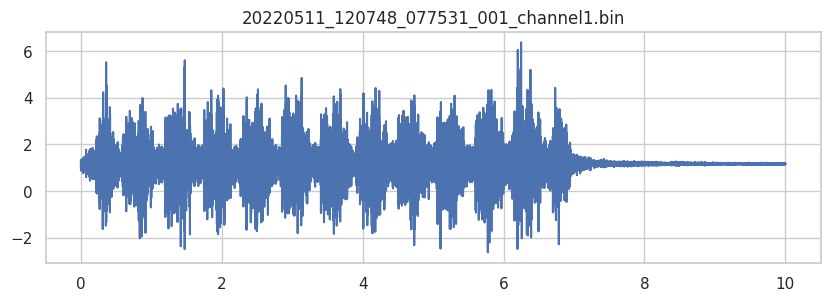

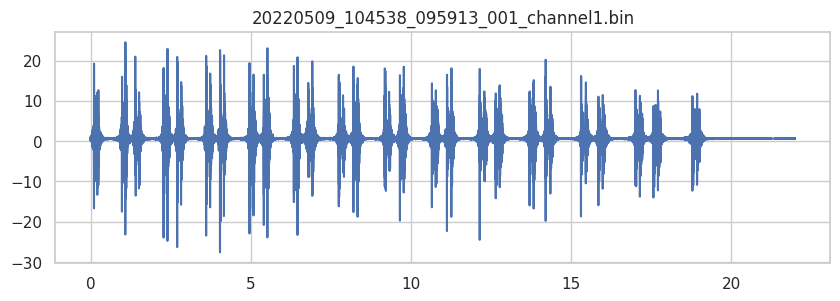

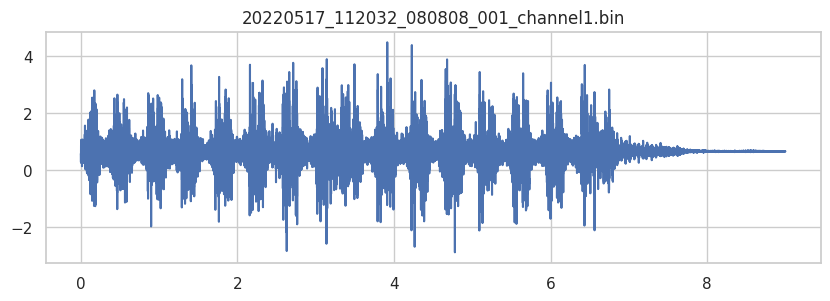

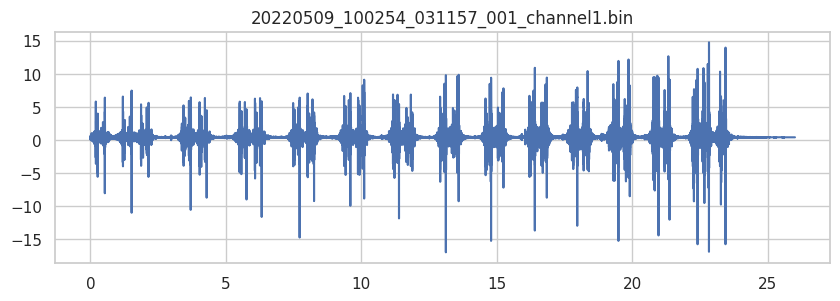

In [23]:
for fname, x in signals.items():
    t = np.arange(len(x))/FS
    plt.figure(figsize=(10,3))
    plt.plot(t, x)
    plt.title(fname)
    plt.grid(True)
    plt.show()


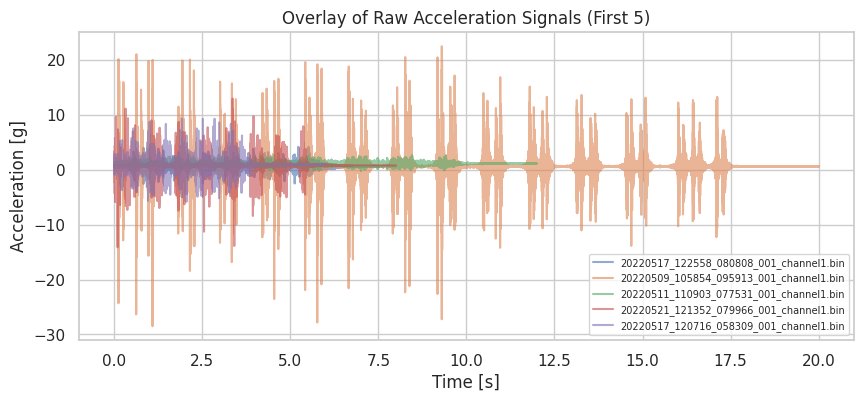

In [24]:
plt.figure(figsize=(10,4))

for fname in list(signals.keys())[:5]:
    x = signals[fname]
    t = np.arange(len(x)) / FS
    plt.plot(t, x, alpha=0.6, label=fname)

plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.title("Overlay of Raw Acceleration Signals (First 5)")
plt.legend(fontsize=7)
plt.grid(True)
plt.show()


In [25]:
signals_filt = {}
segments = {}

for fname, x in signals.items():
    xf = bandpass_filter_zero_phase(x, FS)
    env = rms_envelope(xf, FS)
    s, e = segment_active_region(env, FS)
    signals_filt[fname] = xf
    segments[fname] = (s, e)


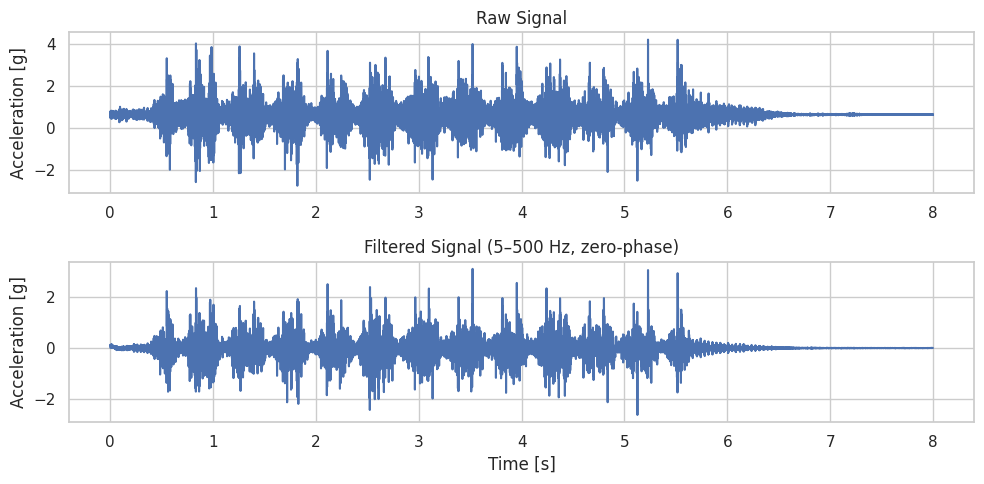

In [26]:
# Raw vs filtered (robust to length mismatches)
example_file = meta_df.index[0]
x_raw = signals[example_file]
x_filt = signals_filt[example_file]

n = min(len(x_raw), len(x_filt))
t = np.arange(n) / FS

plt.figure(figsize=(10,5))

plt.subplot(2,1,1)
plt.plot(t, x_raw[:n])
plt.title("Raw Signal")
plt.ylabel("Acceleration [g]")
plt.grid(True)

plt.subplot(2,1,2)
plt.plot(t, x_filt[:n])
plt.title("Filtered Signal (5–500 Hz, zero-phase)")
plt.xlabel("Time [s]")
plt.ylabel("Acceleration [g]")
plt.grid(True)

plt.tight_layout()
plt.show()

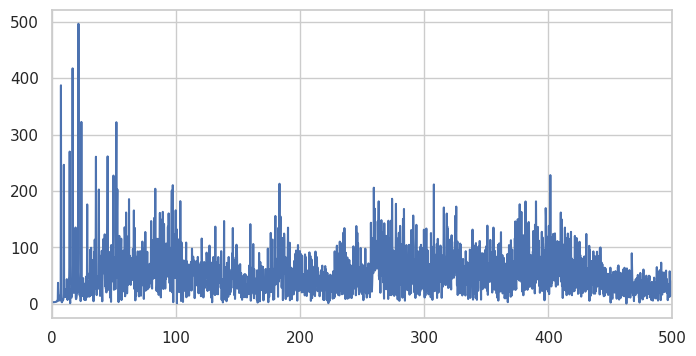

In [27]:
fname = list(signals.keys())[0]
s, e = segments[fname]
xseg = signals_filt[fname][s:e]

yf = np.abs(rfft(xseg))
xf = rfftfreq(len(xseg), 1/FS)

plt.figure(figsize=(8,4))
plt.plot(xf, yf)
plt.xlim(0, 500)
plt.grid(True)
plt.show()


In [28]:
rows = []
for fname in meta_df.index:
    s, e = segments[fname]
    xseg = signals_filt[fname][s:e]

    feats = {}
    feats.update(parse_filename_metadata(fname))
    feats.update(extract_time_features(xseg, FS))
    feats.update(extract_frequency_features(xseg, FS))
    feats["active_duration_s"] = (e-s)/FS
    feats["file"] = fname
    rows.append(feats)

features_df = pd.DataFrame(rows).set_index("file")
features_df


,date,time,sensor_id,rms,peak_to_peak,num_peaks,mean_peak_interval_s,spectral_centroid_hz,dominant_frequency_hz,active_duration_s
file,,,,,,,,,,
20220517_122558_080808_001_channel1.bin,20220517,122558,080808,0.471155,5.744728,1167,0.004371,267.979824,21.174395,5.1005
20220509_105854_095913_001_channel1.bin,20220509,105854,095913,1.570273,44.038942,1716,0.010048,275.537639,153.950000,20.0000
20220511_110903_077531_001_channel1.bin,20220511,110903,077531,0.274914,2.739692,2632,0.003360,281.152262,42.849067,8.8450
20220521_121352_079966_001_channel1.bin,20220521,121352,079966,1.113906,21.922877,997,0.005470,242.206566,73.500000,8.0000
20220517_120716_058309_001_channel1.bin,20220517,120716,058309,0.986060,12.799808,375,0.006274,281.614718,93.231162,2.3490
20220509_091022_031264_001_channel1.bin,20220509,091022,031264,1.490862,33.531185,2027,0.007091,270.079287,195.058824,17.0000
20220507_131853_065205_001_channel1.bin,20220507,131853,065205,6.829386,153.924298,510,0.008943,269.302788,71.714286,7.0000
20220507_131544_065205_001_channel1.bin,20220507,131544,065205,6.119571,147.311505,583,0.008562,268.039206,65.375000,8.0000
20220521_121722_079966_001_channel1.bin,20220521,121722,079966,1.497176,18.834176,555,0.006267,254.132015,92.842771,3.4790


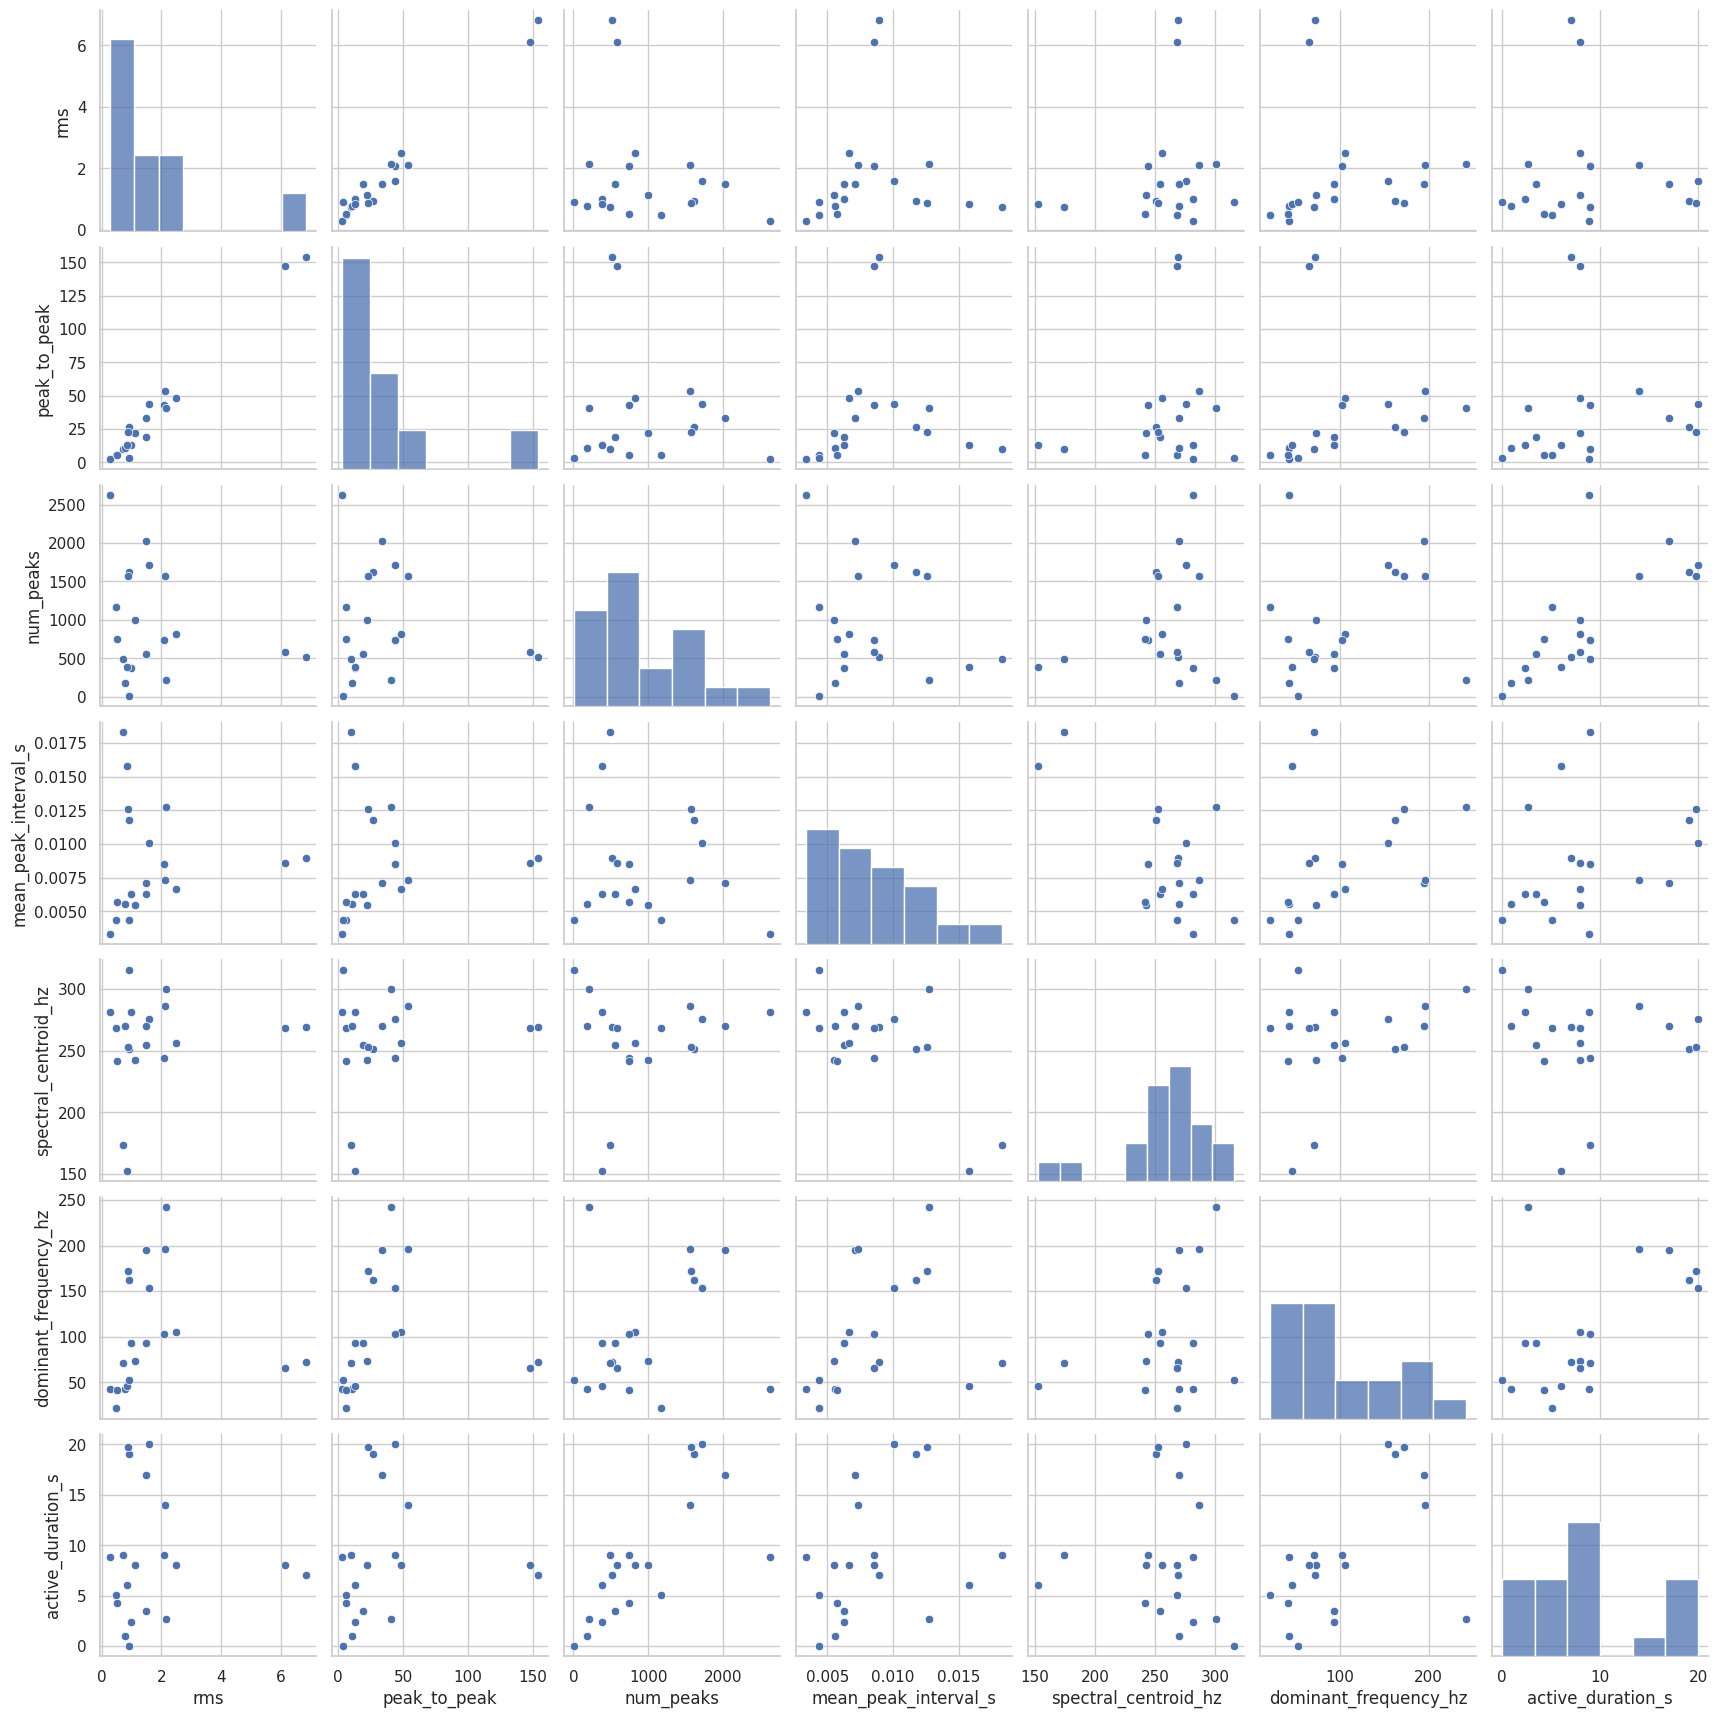

In [29]:
sns.pairplot(features_df.select_dtypes(np.number).dropna())
plt.show()



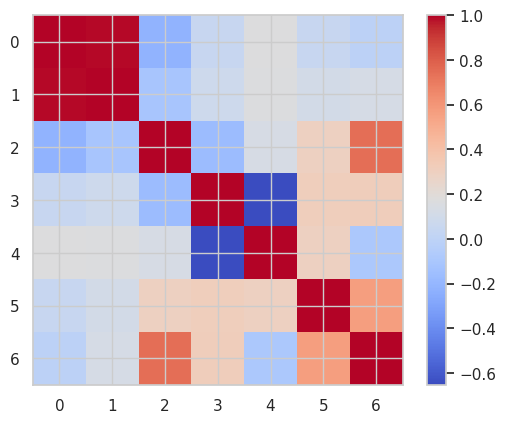

In [30]:
corr = features_df.select_dtypes(np.number).corr()
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.show()


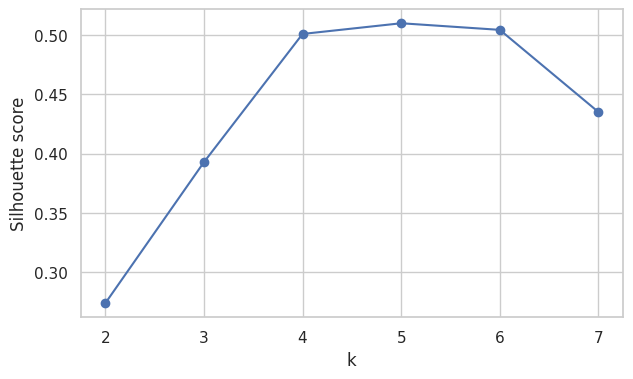

Selected k: 5


In [31]:
from sklearn.metrics import silhouette_score

# Select numeric features only
X = features_df.select_dtypes(include=[np.number])

# Fill NaNs using column-wise numeric mean
X = X.fillna(X.mean())

# Scale features
X_scaled = StandardScaler().fit_transform(X)

# --- Silhouette analysis ---
k_range = range(2, 8)
scores = []

for k in k_range:
    labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7,4))
plt.plot(k_range, scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()

best_k = k_range[np.argmax(scores)]
print("Selected k:", best_k)

# --- Final KMeans ---
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

features_df["cluster"] = clusters


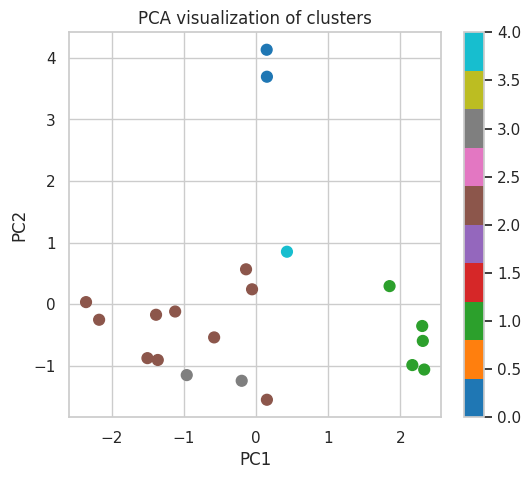

In [32]:
pca = PCA(n_components=2)
Xp = pca.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
plt.scatter(Xp[:,0], Xp[:,1], c=clusters, cmap="tab10", s=60)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA visualization of clusters")
plt.colorbar()
plt.show()


In [33]:
features_df.groupby("cluster").mean(numeric_only=True)


,rms,peak_to_peak,num_peaks,mean_peak_interval_s,spectral_centroid_hz,dominant_frequency_hz,active_duration_s
cluster,,,,,,,
0,6.474478,150.617901,546.5,0.008752,268.670997,68.544643,7.50000
1,1.394466,36.179997,1700.4,0.009751,267.132755,175.956375,17.96080
2,1.113163,17.388662,821.7,0.005659,265.397341,66.870049,5.00665
3,0.789132,11.266974,438.5,0.017029,163.069435,58.703348,7.52750
4,2.135149,40.934781,213.0,0.012759,300.271600,242.379457,2.70650


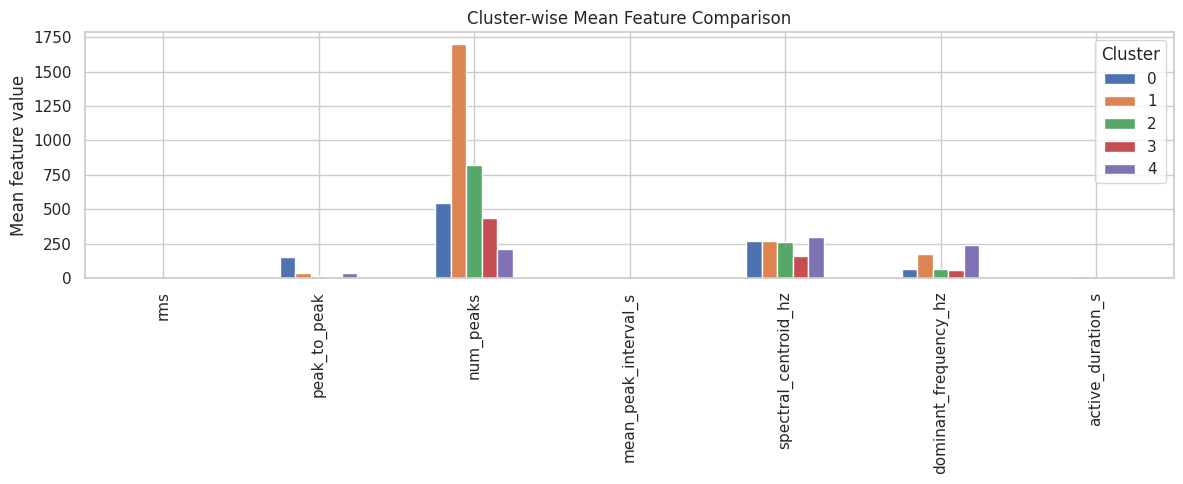

In [34]:
cluster_means = features_df.groupby("cluster").mean(numeric_only=True)

cluster_means.T.plot(
    kind="bar",
    figsize=(12,5)
)

plt.ylabel("Mean feature value")
plt.title("Cluster-wise Mean Feature Comparison")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
# %%
features_df["speed_proxy"] = 1.0 / features_df["mean_peak_interval_s"]
features_df[["mean_peak_interval_s", "speed_proxy"]]


,mean_peak_interval_s,speed_proxy
file,,
20220517_122558_080808_001_channel1.bin,0.004371,228.784460
20220509_105854_095913_001_channel1.bin,0.010048,99.521253
20220511_110903_077531_001_channel1.bin,0.003360,297.641269
20220521_121352_079966_001_channel1.bin,0.005470,182.802606
20220517_120716_058309_001_channel1.bin,0.006274,159.386320
20220509_091022_031264_001_channel1.bin,0.007091,141.022518
20220507_131853_065205_001_channel1.bin,0.008943,111.818981
20220507_131544_065205_001_channel1.bin,0.008562,116.797110
20220521_121722_079966_001_channel1.bin,0.006267,159.562212


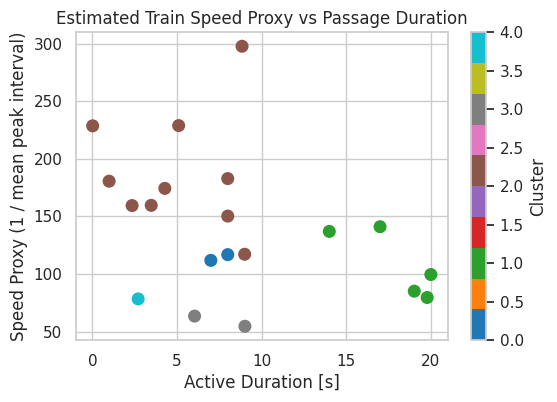

In [36]:
# %%
plt.figure(figsize=(6,4))
plt.scatter(
    features_df["active_duration_s"],
    features_df["speed_proxy"],
    c=features_df["cluster"],
    cmap="tab10",
    s=70
)
plt.xlabel("Active Duration [s]")
plt.ylabel("Speed Proxy (1 / mean peak interval)")
plt.title("Estimated Train Speed Proxy vs Passage Duration")
plt.colorbar(label="Cluster")
plt.grid(True)
plt.show()


<Figure size 600x400 with 0 Axes>

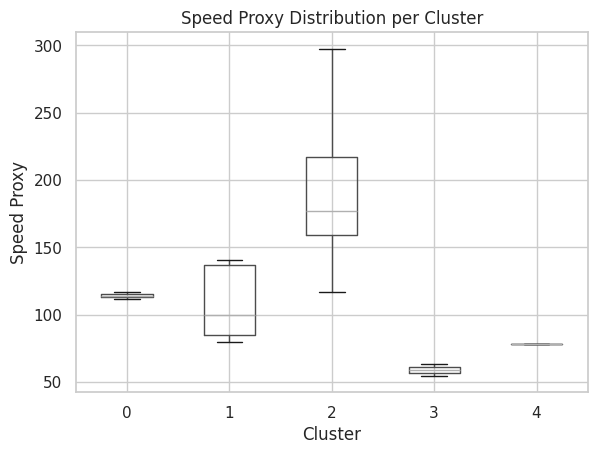

In [37]:
# %%
plt.figure(figsize=(6,4))
features_df.boxplot(column="speed_proxy", by="cluster")
plt.title("Speed Proxy Distribution per Cluster")
plt.suptitle("")
plt.xlabel("Cluster")
plt.ylabel("Speed Proxy")
plt.grid(True)
plt.show()


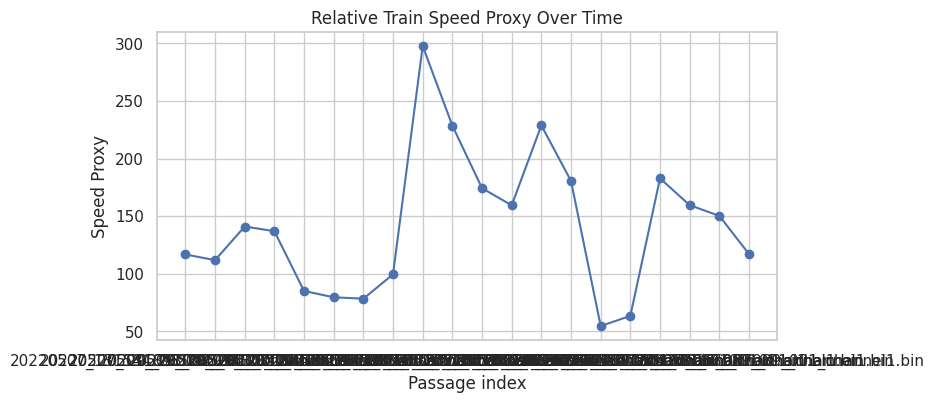

In [38]:
# %%
features_df_sorted = features_df.sort_index()

plt.figure(figsize=(8,4))
plt.plot(features_df_sorted["speed_proxy"], marker="o")
plt.xlabel("Passage index")
plt.ylabel("Speed Proxy")
plt.title("Relative Train Speed Proxy Over Time")
plt.grid(True)
plt.show()


In [39]:
# %%
features_df.groupby("cluster")[["speed_proxy"]].agg(["mean", "std", "min", "max"])


speed_proxy                                   
               mean        std         min         max
cluster                                               
0        114.308045   3.520069  111.818981  116.797110
1        108.440039  28.863210   79.599474  141.022518
2        187.894378  51.291392  117.125673  297.641269
3         59.052756   6.237213   54.642381   63.463132
4         78.373383        NaN   78.373383   78.373383

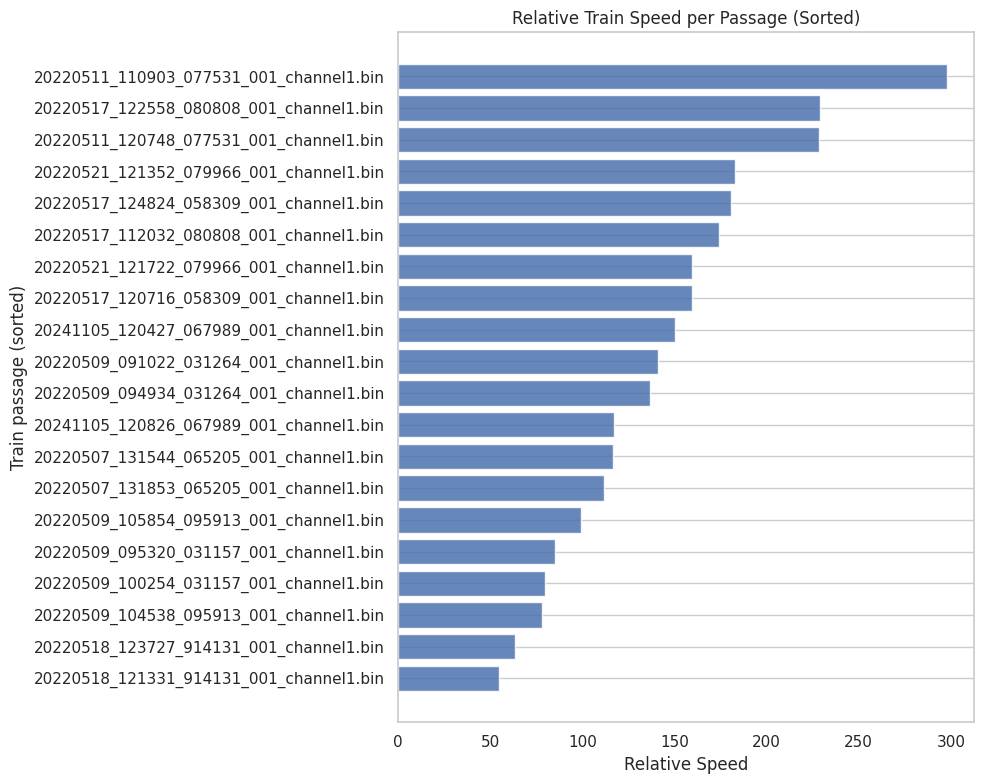

In [48]:
# %%
features_df_sorted = features_df.sort_values("speed_proxy")

plt.figure(figsize=(10,8))
plt.barh(
    features_df_sorted.index,
    features_df_sorted["speed_proxy"],
    #color="darkorange",
    alpha=0.85
)

plt.xlabel("Relative Speed")
plt.ylabel("Train passage (sorted)")
plt.title("Relative Train Speed per Passage (Sorted)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()


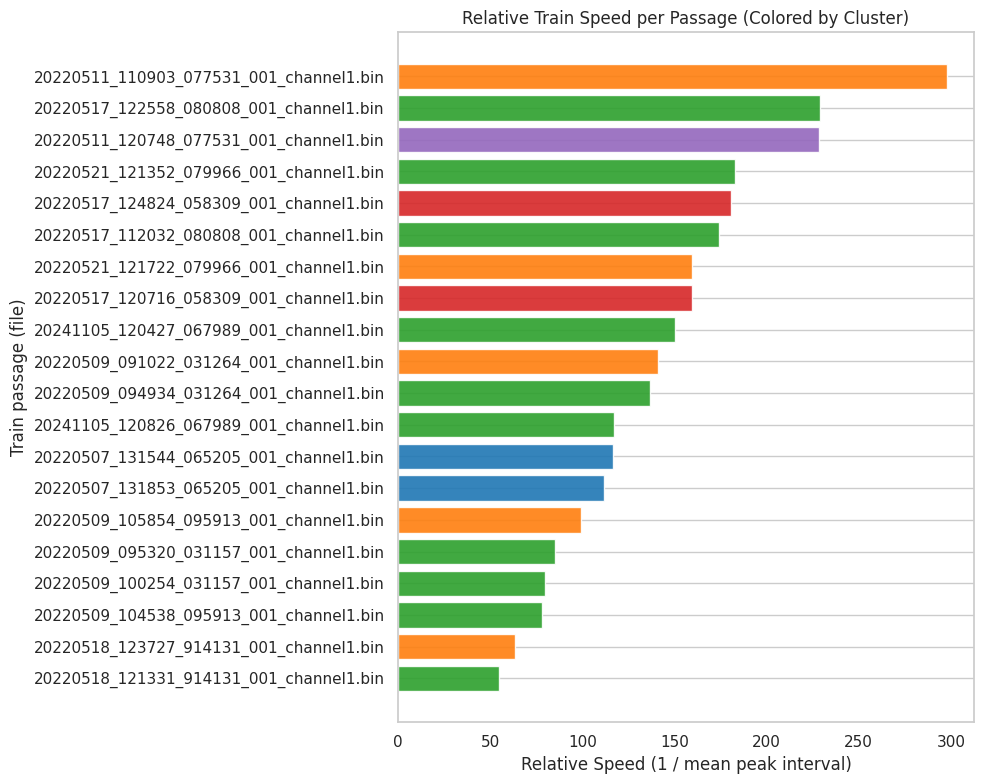

In [49]:
# %%
features_df_sorted = features_df.sort_values("speed_proxy")
plt.figure(figsize=(10,8))

palette = sns.color_palette("tab10", features_df_sorted["cluster"].nunique())
color_map = dict(enumerate(palette))
colors = features_df["cluster"].map(color_map)

plt.barh(
    features_df_sorted.index,
    features_df_sorted["speed_proxy"],
    color=colors,
    alpha=0.9
)

plt.xlabel("Relative Speed (1 / mean peak interval)")
plt.ylabel("Train passage (file)")
plt.title("Relative Train Speed per Passage (Colored by Cluster)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()
